In [3]:
from matplotlib import pyplot as plt
from scipy.signal import lombscargle
import numpy as np

from arvi import RV
import kima

In [4]:
s = RV("TOI-2449")

querying Simbad...
querying Gaia...
querying Simbad...
querying ExoFOP...
querying DACE for TOI-2449...
RVs available from
   CORALIE14 ├ DRS-3.3.12-CCF - CORALIE (38 observations)
   CORALIE24 ├ DRS-3.3.12-CCF - CORALIE (2 observations)
  ESPRESSO19 ├ DRS-3.3.10-CCF - SINGLEHR21 (82 observations)
     HARPS15 ├ DRS-3.3.6-CCF - HARPS (54 observations)
using Gaia information to remove secular acceleration
removing secular acceleration from RVs
subtracted weighted average from CORALIE14 : (-3378.987 m/s)
subtracted weighted average from HARPS15   : (-3532.507 m/s)
subtracted weighted average from ESPRESSO19: (-3522.347 m/s)
subtracted weighted average from CORALIE24 : (-3409.847 m/s)
subtracted weighted averages from ('ccf_fwhm', 'ccf_bispan')


In [5]:
s.remove_instrument("ESPRESSO19")

Removed observations from 'ESPRESSO19'


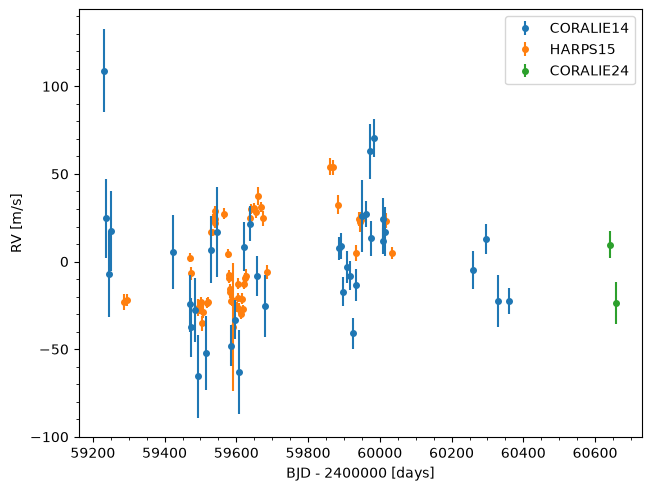

In [6]:
fig, axs = s.plot()
plt.show()

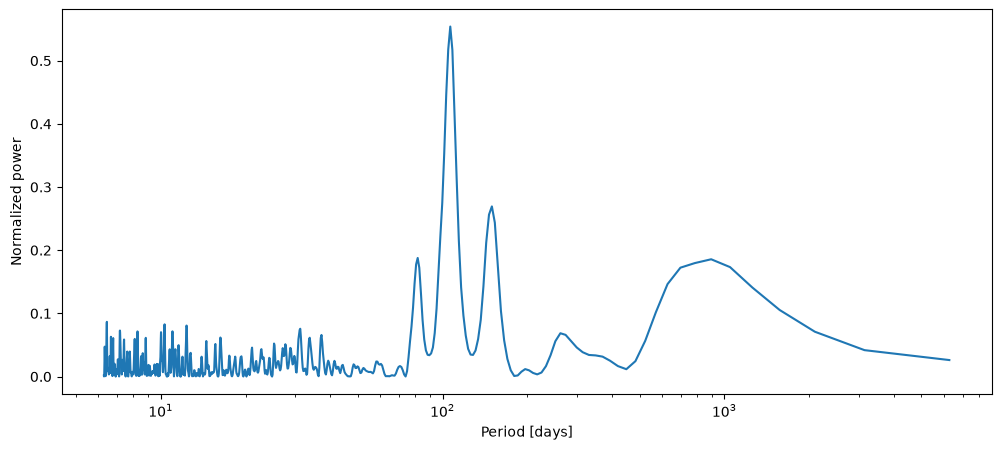

In [7]:
t = s.time      # timestamp of measurement in Barycentric Julian Date - 2.400.000 [days] 
vrad = s.vrad   # radial velocity measurement [m/s]
err = s.svrad   # error on radial velocity measurement [m/s]


# Lomb–Scargle periodogram

freq = np.linspace(0.001, 1, 1000)
period = 2 * np.pi / freq
pgram = lombscargle(t, vrad, freq, normalize=True)

fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(period, pgram)
ax.set_xscale("log")
ax.set_xlabel("Period [days]")
ax.set_ylabel("Normalized power")
plt.show()

In [8]:
max_idx = np.argmax(pgram)
max_f = freq[max_idx]

best_period = 2*np.pi / max_f
print(best_period)

106.49466622338281


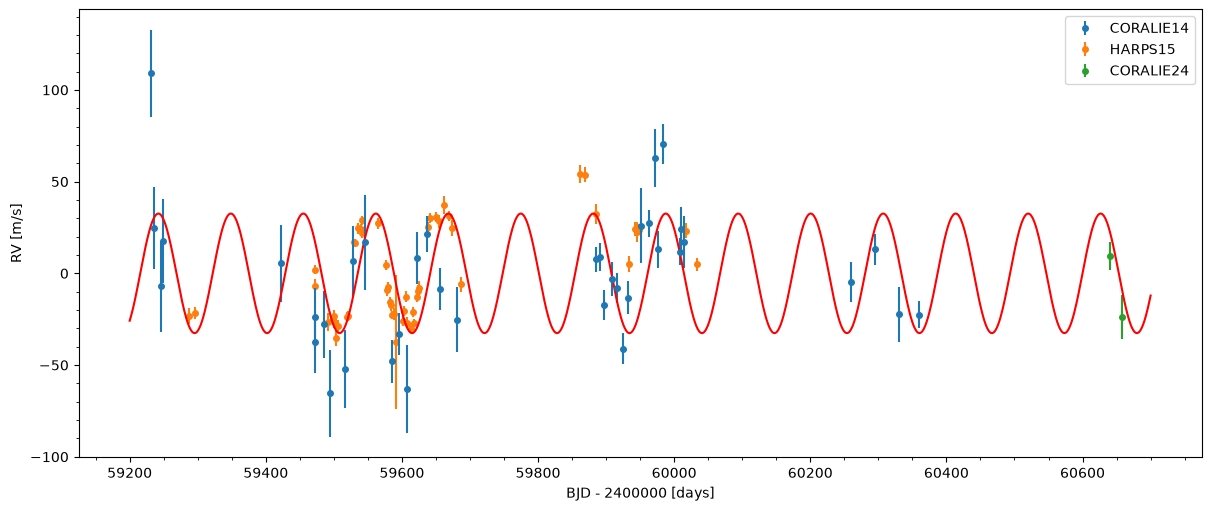

In [28]:
def basic_sine(time, amp, per, hor_shift, vert_shift): # It's not just a sine function, but more complicated
    y = amp*np.sin(per*(time - hor_shift)) + vert_shift
    return y

time = np.linspace(59200, 60700, 1500)
fit = basic_sine(time=time, amp=32.580875, per=2*np.pi/best_period, hor_shift=4.491824, vert_shift=0)

fig, axs = s.plot()
fig.set_size_inches(12, 5)
plt.plot(time, fit, c="red", zorder=0)
plt.show()


In [52]:
# fit keplerian motion

def keplerian(a, e, i, nu, omega, P, m_p, m_s):
    K = m_p / (m_s + m_p) * 2*np.pi*a*np.sin(i) / (P*np.sqrt(1-e**2))
    V = K*(np.cos(nu+omega) + e*np.cos(omega))
    return V

m_s = 1.079*1.989e30 # mass of the star in kg
P = best_period # best period according to the periodogram in days

